# EDA: ImageNet100 Dataset

Explore the structure, statistics, and sample images from ImageNet100.

## Expected structure:
- `data/raw/imagenet100/train/<class_id>/image.jpg`
- `data/raw/imagenet100/val/<class_id>/image.jpg`
- `data/raw/imagenet100/Labels.json` (optional, maps class_id to description)

In [2]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Paths
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
DATA_ROOT = PROJECT_ROOT / 'data' / 'raw' / 'imagenet100'
TRAIN_DIR = DATA_ROOT / 'train'
VAL_DIR = DATA_ROOT / 'val'
LABELS_JSON = DATA_ROOT / 'Labels.json'
FIGURES_DIR = PROJECT_ROOT / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Notebook dir: {NOTEBOOK_DIR}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Data root: {DATA_ROOT}")
print(f"Train dir exists: {TRAIN_DIR.exists()}")
print(f"Val dir exists: {VAL_DIR.exists()}")
print(f"Labels JSON exists: {LABELS_JSON.exists()}")

Notebook dir: c:\Users\giova\Universita\deep_learning\Masked-Autoencoders-for-Image-Representation-Learning\notebooks
Project root: c:\Users\giova\Universita\deep_learning\Masked-Autoencoders-for-Image-Representation-Learning
Data root: c:\Users\giova\Universita\deep_learning\Masked-Autoencoders-for-Image-Representation-Learning\data\raw\imagenet100
Train dir exists: True
Val dir exists: True
Labels JSON exists: True


## Load Labels (if available)

In [3]:
labels_dict = {}
if LABELS_JSON.exists():
    with open(LABELS_JSON, 'r') as f:
        labels_dict = json.load(f)
    print(f"Loaded {len(labels_dict)} class labels")
    print("\nSample labels:")
    for i, (k, v) in enumerate(list(labels_dict.items())[:5]):
        print(f"  {k}: {v}")
else:
    print("Labels.json not found")

Loaded 100 class labels

Sample labels:
  n01968897: chambered nautilus, pearly nautilus, nautilus
  n01770081: harvestman, daddy longlegs, Phalangium opilio
  n01818515: macaw
  n02011460: bittern
  n01496331: electric ray, crampfish, numbfish, torpedo


## Count images per split

In [4]:
def count_images_in_split(split_dir):
    """Count images per class in a split directory."""
    class_counts = {}
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.JPEG'}
    
    if not split_dir.exists():
        print(f"Directory not found: {split_dir}")
        return class_counts
    
    for class_dir in sorted(split_dir.iterdir()):
        if class_dir.is_dir():
            count = sum(1 for f in class_dir.iterdir() if f.suffix.lower() in image_extensions)
            if count > 0:
                class_counts[class_dir.name] = count
    
    return class_counts

train_counts = count_images_in_split(TRAIN_DIR)
val_counts = count_images_in_split(VAL_DIR)

print(f"Train split:")
print(f"  Classes: {len(train_counts)}")
print(f"  Total images: {sum(train_counts.values())}")
print(f"  Images per class (mean): {np.mean(list(train_counts.values())):.1f}")
print(f"  Images per class (min-max): {min(train_counts.values())}-{max(train_counts.values())}")

print(f"\nVal split:")
print(f"  Classes: {len(val_counts)}")
print(f"  Total images: {sum(val_counts.values())}")
print(f"  Images per class (mean): {np.mean(list(val_counts.values())):.1f}")
print(f"  Images per class (min-max): {min(val_counts.values())}-{max(val_counts.values())}")

Train split:
  Classes: 100
  Total images: 130000
  Images per class (mean): 1300.0
  Images per class (min-max): 1300-1300

Val split:
  Classes: 100
  Total images: 5000
  Images per class (mean): 50.0
  Images per class (min-max): 50-50


## Visualize sample images from random classes

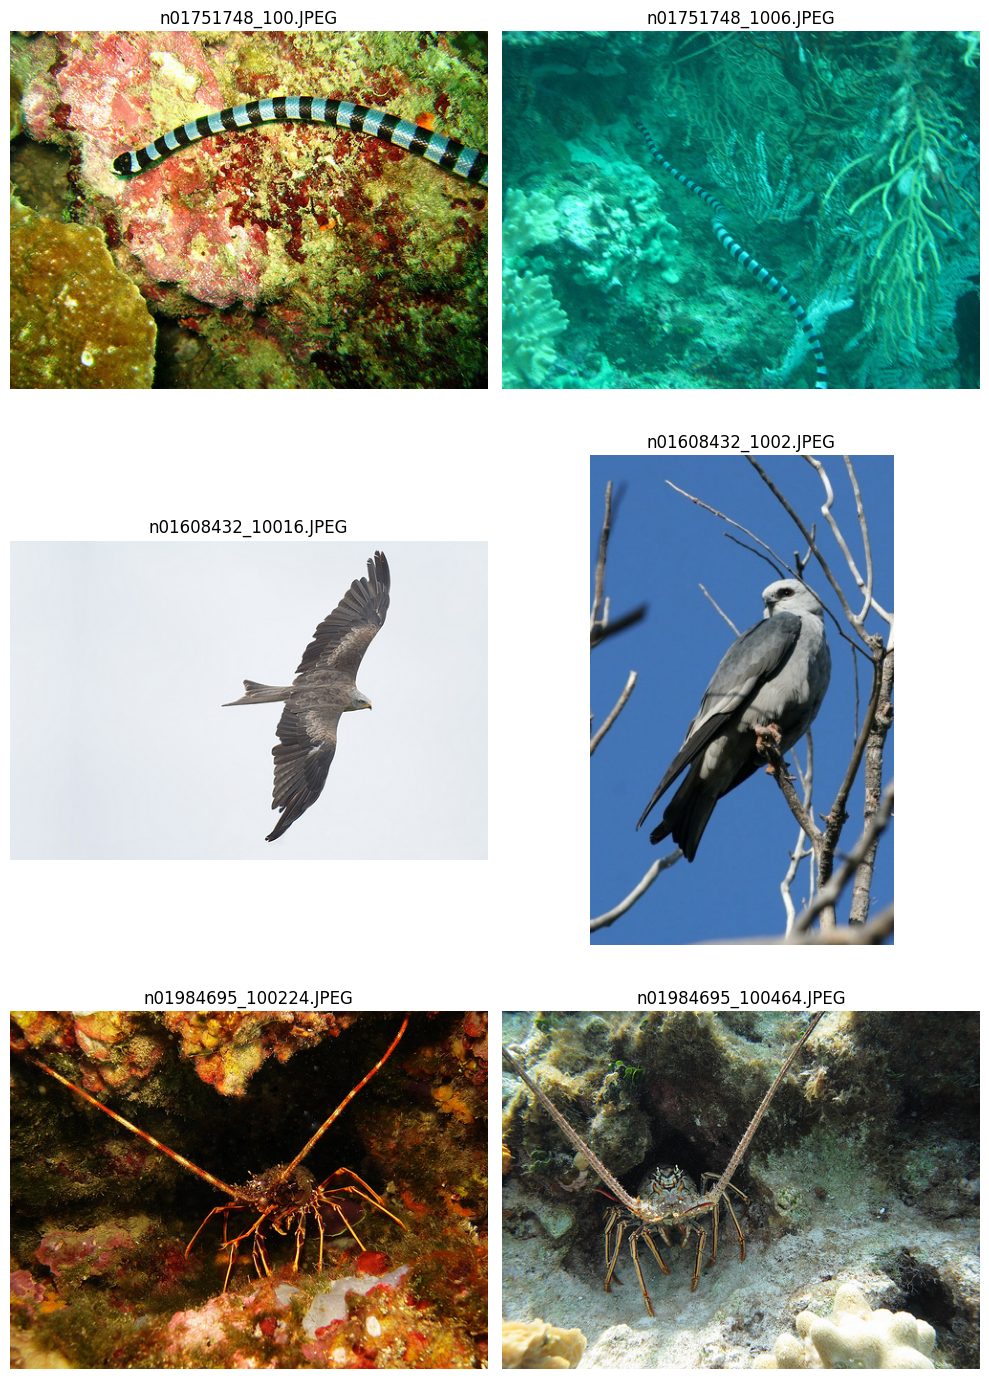

Saved sample images to c:\Users\giova\Universita\deep_learning\Masked-Autoencoders-for-Image-Representation-Learning\figures\01_sample_imagenet100_images.png


In [5]:
import random


def get_image_files(class_dir, max_count=5):
    """Get up to max_count image files from a class directory."""
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.JPEG'}
    images = [f for f in class_dir.iterdir() if f.suffix.lower() in image_extensions]
    return images[:max_count]

# Select 3 random classes from train
sample_classes = random.sample(list(train_counts.keys()), min(3, len(train_counts)))
fig, axes = plt.subplots(len(sample_classes), 2, figsize=(10, 5 * len(sample_classes)))

if len(sample_classes) == 1:
    axes = [axes]

for idx, class_id in enumerate(sample_classes):
    class_label = labels_dict.get(class_id, class_id)
    class_dir = TRAIN_DIR / class_id
    images = get_image_files(class_dir, max_count=2)
    
    for img_idx, img_path in enumerate(images):
        if img_idx < 2:
            try:
                img = Image.open(img_path)
                if len(sample_classes) == 1:
                    ax = axes[img_idx]
                else:
                    ax = axes[idx, img_idx]
                ax.imshow(img)
                if img_idx == 0:
                    ax.set_ylabel(class_label, fontsize=10)
                ax.set_title(f"{img_path.name}")
                ax.axis('off')
            except Exception as e:
                print(f"Error loading {img_path}: {e}")

plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_sample_imagenet100_images.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Saved sample images to {FIGURES_DIR / '01_sample_imagenet100_images.png'}")

## Plot class distribution

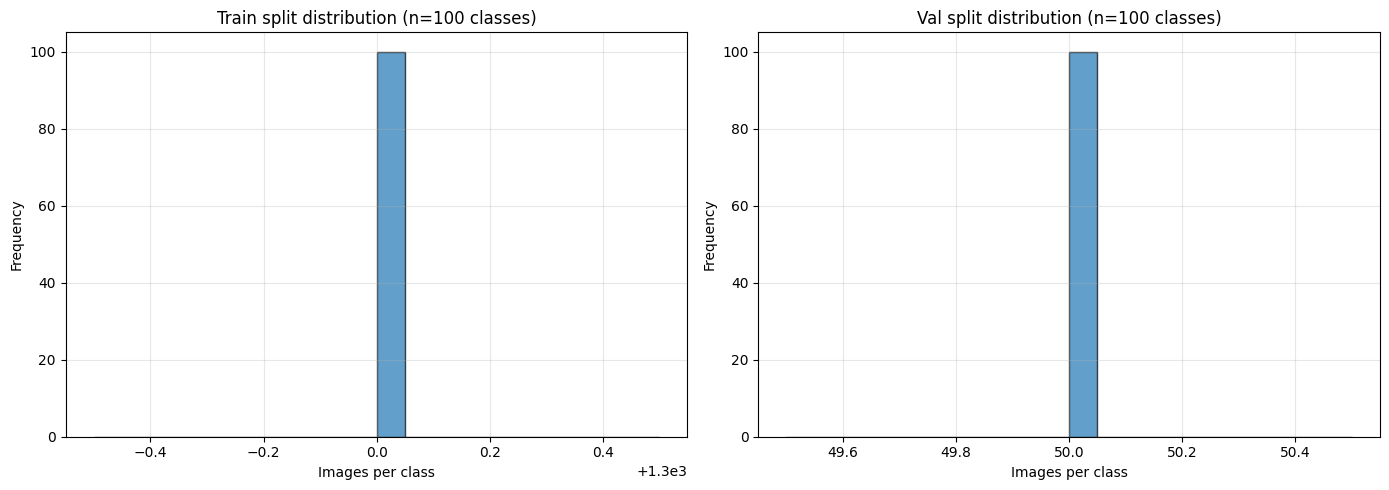

Saved class distribution plots to c:\Users\giova\Universita\deep_learning\Masked-Autoencoders-for-Image-Representation-Learning\figures\01_imagenet100_class_distribution.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train distribution
train_values = list(train_counts.values())
axes[0].hist(train_values, bins=20, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Images per class')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Train split distribution (n={len(train_counts)} classes)')
axes[0].grid(alpha=0.3)

# Val distribution
val_values = list(val_counts.values())
axes[1].hist(val_values, bins=20, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Images per class')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Val split distribution (n={len(val_counts)} classes)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_imagenet100_class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Saved class distribution plots to {FIGURES_DIR / '01_imagenet100_class_distribution.png'}")

## Check image size variations

In [ ]:
# Sample ~50 random images and check sizes
image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.JPEG'}
all_images = list(TRAIN_DIR.rglob('*'))
all_images = [f for f in all_images if f.is_file() and f.suffix.lower() in image_extensions]
sample_images = random.sample(all_images, min(50, len(all_images)))

sizes = []
for img_path in sample_images:
    try:
        img = Image.open(img_path)
        sizes.append(img.size)  # (width, height)
    except Exception as e:
        print(f"Error loading {img_path}: {e}")

if sizes:
    widths = [s[0] for s in sizes]
    heights = [s[1] for s in sizes]
    print(f"Image size statistics (sampled from {len(sizes)} images):")
    print(f"  Width: min={min(widths)}, max={max(widths)}, mean={np.mean(widths):.1f}")
    print(f"  Height: min={min(heights)}, max={max(heights)}, mean={np.mean(heights):.1f}")
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].scatter(widths, heights, alpha=0.6, s=50)
    axes[0].set_xlabel('Width (pixels)')
    axes[0].set_ylabel('Height (pixels)')
    axes[0].set_title(f'Image aspect ratio (n={len(sizes)} samples)')
    axes[0].grid(alpha=0.3)
    
    # Histogram of smaller dimension
    min_dims = [min(w, h) for w, h in sizes]
    axes[1].hist(min_dims, bins=20, edgecolor='black', alpha=0.7)
    axes[1].set_xlabel('Min dimension (pixels)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Distribution of min(width, height)')
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '01_imagenet100_image_sizes.png', dpi=100, bbox_inches='tight')
    plt.show()
    print(f"Saved image size plots to {FIGURES_DIR / '01_imagenet100_image_sizes.png'}")